#1: Data Cleaning

In [ ]:
import pandas as pd

df = pd.read_csv("amazon_raw.csv")

print(df.dtypes)
print(df.head())
print(df.shape)
print(df.isnull().sum())

df["discounted_price"] = df["discounted_price"].str.replace("₹", "", regex=False).str.replace(",", "", regex=False).astype(float)
print(df["discounted_price"])

df["actual_price"] = df["actual_price"].str.replace("₹", "", regex=False).str.replace(",", "", regex=False).astype(float)
print(df["actual_price"])

df["discount_percentage"] = df["discount_percentage"].str.replace("%", "", regex=False).astype(float)
print(df["discount_percentage"])

df["rating_count"] = df["rating_count"].str.replace(",", "", regex=False).astype(float)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())
print(df["rating_count"])

print(df.isnull().sum())
df.to_csv("amazon_cleaned.csv", index=False)

#2: Data Transforming

In [ ]:
import pandas as pd

df = pd.read_csv("amazon_cleaned.csv")

df["main_category"] = df["category"].str.split(r"\|", n=1).str[0]
print(df["main_category"])

df["savings"] = df["actual_price"] - df["discounted_price"]
print(df["savings"])

bins1 = [0, 200, 1000, 5000, 20000, float("inf")]
labels1 = ["Under 200", "200 - 1000", "1000 - 5000", "5000 - 20000", "Above 20000"]
df["price_bucket"] = pd.cut(df["actual_price"], bins = bins1, labels = labels1, right= False)
print(df["price_bucket"])

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
bins2 = [0, 1.01, 2.01, 3.01, 4.01, 5.01]
labels2 = ["Poor", "Moderate", "Average", "Good", "Excellent"]
df["rating_label"] = pd.cut(df["rating"], bins = bins2, labels = labels2, right= False)
print(df["rating_label"])

df = df[
    [
        "product_id",
        "product_name",
        "main_category",
        "category",
        "discounted_price",
        "savings",
        "actual_price",
        "price_bucket",
        "discount_percentage",
        "rating",
        "rating_label",
        "rating_count",
        "about_product",
        "user_id",
        "user_name",
        "review_id",
        "review_title",
        "review_content",
        "img_link",
        "product_link"
    ]
]

df.to_csv("amazon_transformed.csv", index = False)

#3: Data analysing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.figure(figsize=(10, 4.5))
sns.histplot(df["discounted_price"].dropna(), bins=30, kde=True)
plt.title("Distribution of Discounted Price")
plt.xlabel("Discounted Price")
plt.ylabel("Count")

plt.figtext(
    0.5, 0.01,
    "Comment: Most products are priced under ₹2,000 - the market is overwhelmingly budget-focused.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

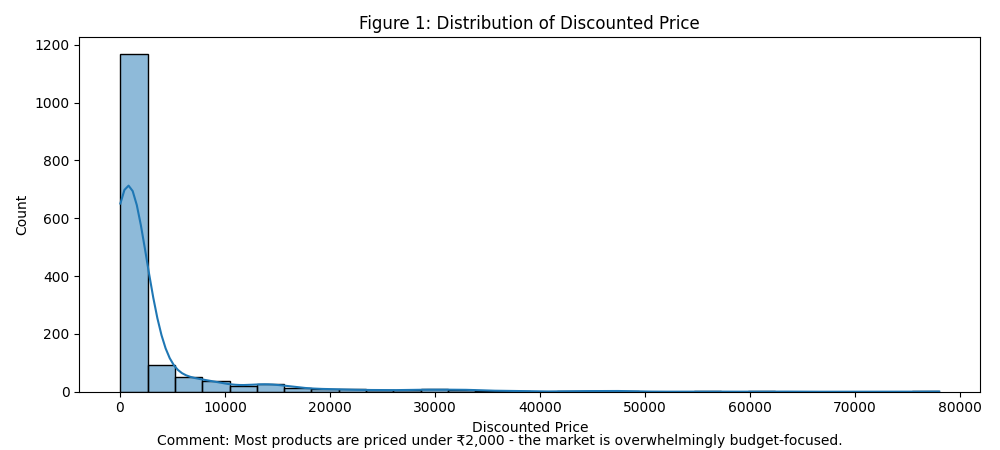

In [ ]:
product_count = df["main_category"].value_counts()

plt.figure(figsize=(10, 4))
sns.barplot(x=product_count.index, y=product_count.values)
plt.title("Number of Products by Main Category")
plt.xlabel("Main Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)

plt.figtext(
    0.5, 0.01,
    "Comment: 3 categories (Electronics, Computers, Home&Kitchen) make up ~97% of the dataset.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

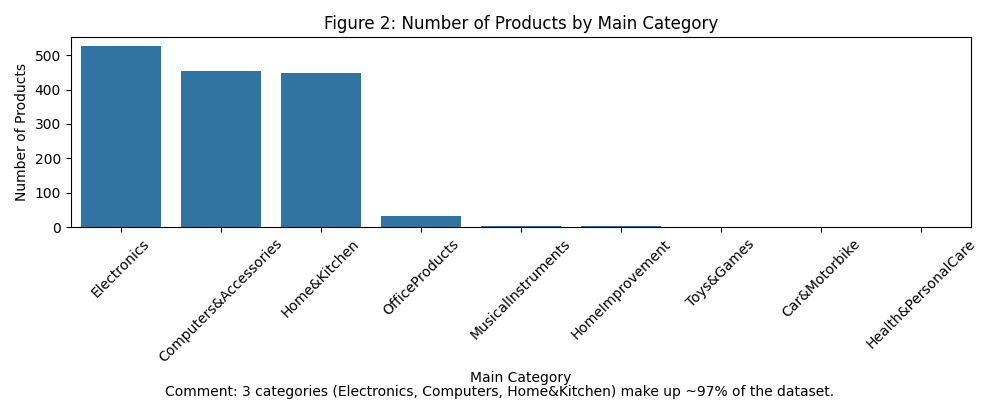

In [ ]:
avg_rating = df.groupby("main_category")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_rating.index, y=avg_rating.values)
plt.title("Average Rating by Main Category")
plt.xlabel("Main Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.figtext(
    0.5, 0.01,
    "Comment: All categories average rate between 3.8-4.3 - suspiciously narrow, suggesting a platform-wide positivity bias.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

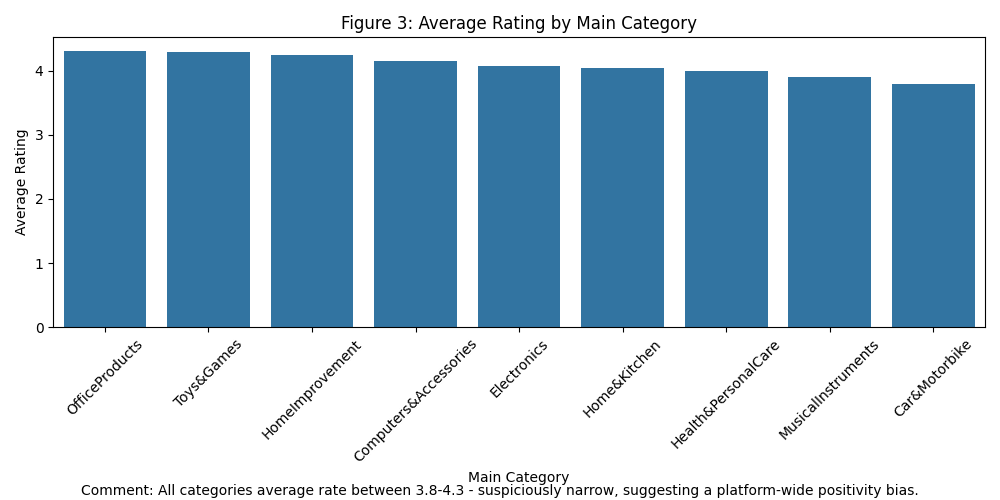

In [ ]:
avg_discount = df.groupby("main_category")["discount_percentage"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_discount.index, y=avg_discount.values)
plt.title("Average Discount Percentage by Main Category")
plt.xlabel("Main Category")
plt.ylabel("Average Discount %")
plt.xticks(rotation=45)

plt.figtext(
    0.5, 0.01,
    "Comment: HomeImprovement discounts the most (~57%), Toys&Games barely discounts at all.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

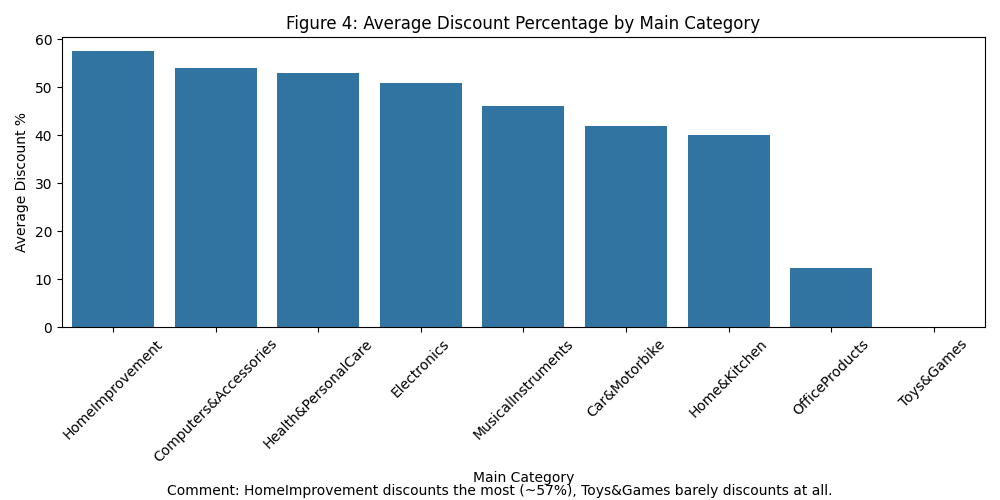

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="actual_price", y="discounted_price", hue="price_bucket", alpha=0.6)
plt.title("Actual Price vs Discounted Price")
plt.xlabel("Actual Price")
plt.ylabel("Discounted Price")

plt.figtext(
    0.5, 0.01,
    "Comment: Price and discount follow a linear trend, but premium products (green, >₹20,000) show the most inconsistent discount depths.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

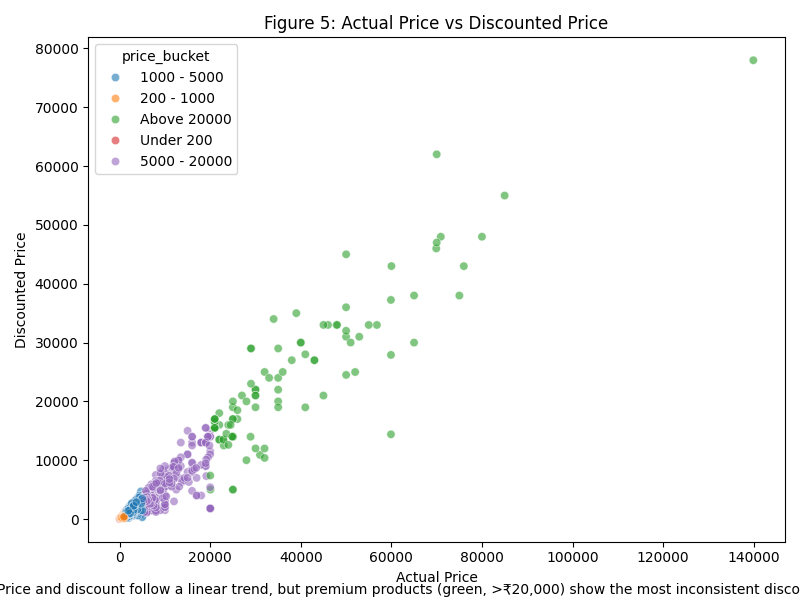